Import libraries

In [ ]:
import os
import numpy as np
import PIL
import torch
from torch.utils.data import Dataset, DataLoader ,random_split
import torchvision
from torchvision.transforms import v2
import cv2
from PIL import Image, ImageFile

Conect to google drive to have access to dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data Preprocessing

Each folder in the dataset has specified in its name whether it is healthy or pest- and disease-infected. The names of the folders are used to find the label of the images. All the images are first passed into PIL.Image.open() to see whether they are broken. If no error occurs, the image path and label will be added into their respective variables.

In [ ]:
class Crop_Dataset(Dataset):
    def __init__(self, root, pests, transform=None):
        self.root = root
        self.pests = pests
        self.img_paths = []
        self.labels = []
        self.numerical_labels = {
            "healthy": 0,
            "pest infested": 1,
            "disease affected": 2
        }
        self.transform = transform

        for folder in os.listdir(self.root):
            matches = [word for word in self.pests if word in folder.lower()]
            if "healthy" in folder.lower():
              label = "healthy"
            elif matches:
              label = "pest infested"
            else:
              label = "disease affected"
            for img in os.listdir(os.path.join(self.root,folder)):
                  try:
                      image = PIL.Image.open(os.path.join(self.root,folder,img)).convert('RGB')
                      self.img_paths.append(os.path.join(self.root,folder,img))
                      self.labels.append(label)
                  except OSError as e:
                      print(f"Warning: Skipping image {os.path.join(self.root,folder,img)} due to error: {e}")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):

        img_path = self.img_paths[idx]

        image = PIL.Image.open(img_path).convert('RGB')

        label = self.numerical_labels[self.labels[idx]]
        if self.transform:
            image = self.transform(image)
        return image, label

All the images are resized to the same size and augmentation is performed on the dataset.

In [ ]:
transform = v2.Compose([
    v2.Resize(256),
    v2.CenterCrop(224),
    v2.RandomHorizontalFlip(p = 0.5),
    v2.RandomRotation(45),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

From observing the name of the folders in the dataset, the name of the pests used were identified and passed into the dataset as a list named pests to be used for finding the labels. The warning signs show the image files that couldn't be opened with PIL.

In [ ]:
full_dataset = Crop_Dataset(root="/content/drive/MyDrive/crop_pest_and_desiase_classification", pests=["mite","miner","armyworm","grasshopper","beetle"], transform = transform)

For splitting the dataset into training, validation, and test sets, random_split is used two times. First, the dataset is divided into 70% training and 30% validation. Then, the validation set is divided into 50% test and 50% validation set. At the end, the dataset is divided into 70% training, 15% validation, and 15% test.

In [ ]:
train_size = int(len(full_dataset) * 0.7)
val_size = len(full_dataset) - train_size
train_dataset, val_set = random_split(full_dataset, [train_size, val_size])

In [ ]:
test_size = int(len(val_set) * 0.5)
val_size = len(val_set) - test_size
val_dataset, test_dataset = random_split(val_set, [val_size, test_size])

Batch size 32 is used for the loaders.

In [ ]:
train_loader = DataLoader(train_dataset,batch_size=32)
val_loader = DataLoader(val_dataset,batch_size=32)
test_loader = DataLoader(test_dataset,batch_size=32)

In [ ]:
for imgs, labels in test_loader:
	continue

# Model Architecture

The ResNet50 is chosen as the model because it provides a decent balance of accuracy and GFLOPS.

In [ ]:
from torchvision.models import resnet50, ResNet50_Weights
from torchsummary import summary

ResNet50 with IMAGENET1K_V1 weights is used for classification. For this model, the FC layer is replaced with a three-output layer.

In [ ]:
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
model.fc = torch.nn.Linear(in_features=model.fc.in_features , out_features=3, bias=True)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 146MB/s]


For fine-tuning the model, all the layers except the FC layer are frozen.

In [ ]:
for name, param in model.named_parameters():
  if 'fc' not in name.lower():
    param.requires_grad = False

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

# Training

For training, validation, and test, functions are written. In the training function, tqdm is used for better visualization of the model process. In the training function, model.train() is used to put the model in the training phase, and in the validation and test functions, model.eval() is used to make the predictions. In the validation and test functions, torch.no_grad() is used to make sure the weights aren't changed. The output of the training and validation functions are the accuracy and the loss of the epoch.

In [ ]:
from tqdm import tqdm
def train(model, data_loader, loss_fn, optimizer, device):
    model.train()
    losses = []
    size = len(data_loader.dataset)
    correct = 0
    loader = tqdm(data_loader, total=len(data_loader))

    for batch, (X, y) in enumerate(loader):
      X, y = X.to(device), y.to(device)
      y_pred = model(X)

      optimizer.zero_grad()
      loss = loss_fn(y_pred, y)
      losses.append(loss.item())

      correct += (y_pred.argmax(1) == y).type(torch.float).sum().item()

      loss.backward()
      optimizer.step()

      loader.set_postfix({"loss": loss.item()})

    return np.mean(losses), correct/size


In [ ]:
def val(model, data_loader, loss_fn, optimizer, device):
    model.eval()
    losses = []
    size = len(data_loader.dataset)
    correct = 0

    with torch.no_grad():
      for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        losses.append(loss.item())

        correct += (y_pred.argmax(1) == y).type(torch.float).sum().item()


    return np.mean(losses), correct/size

To build the confusion matrix, the test function outputs the model predictions and test labels along with the test set accuracy and loss.

In [ ]:
def test(model, data_loader, loss_fn, optimizer, device):
    model.eval()
    losses = []
    y_preds = []
    y_test = []
    size = len(data_loader.dataset)
    correct = 0

    with torch.no_grad():
      for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        y_preds.append(y_pred.cpu())
        y_test.append(y.cpu())

        loss = loss_fn(y_pred, y)
        losses.append(loss.item())

        correct += (y_pred.argmax(1) == y).type(torch.float).sum().item()


    return np.mean(losses), correct/size, y_preds, y_test

For the optimizer, Adam with a learning rate of 0.001 is used. For the loss function, the CrossEntropyLoss is chosen. Ten epochs were chosen.

In [ ]:
epochs = 10
learning_rate = 0.001
device = "cuda" if torch.cuda.is_available() else "cpu"
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In train_losses and validation_losses, the values of train_loss and val_loss are appended for each epoch to be able to plot the process of training after the training is done.

In [ ]:
train_losses = []
validation_losses = []

In [ ]:
for epoch in range(1, epochs+1):
  train_loss, train_acc = train(model, train_loader, loss_fn, optimizer, device)
  val_loss, val_acc = val(model, val_loader, loss_fn, optimizer, device)
  train_losses.append(train_loss)
  validation_losses.append(val_loss)
  print(f"Epoch {epoch}/{epochs}:")
  print(f"Train - Loss: {train_loss}
  print(f"Validation - Loss: {val_loss}, Acc: {val_acc}")

100%|██████████| 550/550 [02:51<00:00,  3.20it/s, loss=0.457]


Epoch 1/10:
Train - Loss: 0.43018366155299276, Acc: 0.8358633236682017
Validation - Loss: 0.34575105988878313, Acc: 0.8676392572944297


100%|██████████| 550/550 [02:54<00:00,  3.15it/s, loss=0.3]


Epoch 2/10:
Train - Loss: 0.33460420910607686, Acc: 0.8708283586332367
Validation - Loss: 0.3111663549128225, Acc: 0.879840848806366


100%|██████████| 550/550 [02:54<00:00,  3.16it/s, loss=0.372]


...

Epoch 8/10:
Train - Loss: 0.2688364557718689, Acc: 0.897151628858946
Validation - Loss: 0.257331704752425, Acc: 0.9007957559681697


100%|██████████| 550/550 [02:58<00:00,  3.09it/s, loss=0.36]


Epoch 9/10:
Train - Loss: 0.2695114426992156, Acc: 0.8991983626129968
Validation - Loss: 0.25817329925879584, Acc: 0.9


100%|██████████| 550/550 [02:55<00:00,  3.13it/s, loss=0.255]


Epoch 10/10:
Train - Loss: 0.26529755871404304, Acc: 0.9002785832054124
Validation - Loss: 0.25495449232600503, Acc: 0.903183023872679


The training and validation losses are plotted to show the progression of the model through the epochs.

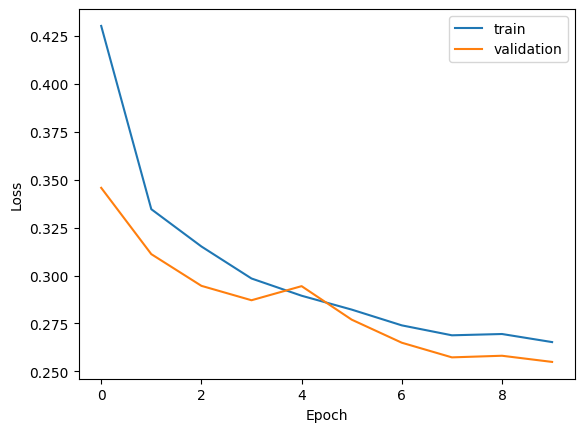

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='train')
plt.plot(validation_losses, label='validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluation

The test_loader is passed into the test function to have the test loss, test accuracy, model predictions and test set labels

In [ ]:
test_loss, test_acc, predictions,y_test = test(model, test_loader, loss_fn, optimizer, device)
print(f"Test - Loss: {test_loss}, Acc: {test_acc}")

Test - Loss: 0.2560318671798302, Acc: 0.9047492703634916


To visualize the confusion matrix of the model, the test labels should be taken out of the batch and placed next to each other. Also, the predictions should have the same operation applied to the classes with the highest value.

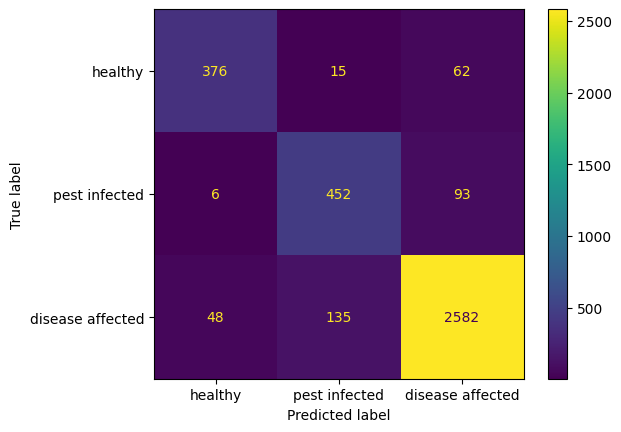

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_test = torch.cat(y_test)
predictions = torch.cat(predictions).argmax(1)

cm = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay( cm, display_labels=["healthy", "pest infected", "disease affected"]).plot()